In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Hilbot chatbot (1)/Hilbot-FI/full_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (1525, 4)

Columns:
['text', 'clean_text', 'label', 'source']

First 10 rows:


,text,clean_text,label,source
0,Hi there,hi there,greeting,json
1,Is anyone there?,anyone there,greeting,json
2,"Hey, how are you doing?",hey doing,greeting,json
3,Hola,hola,greeting,json
4,Hello,hello,greeting,json
5,"Hello there, good day to you!",hello there good day,greeting,json
6,Greetings!,greetings,greeting,json
7,Howdy!,howdy,greeting,json
8,"Hey, is someone available?",hey someone available,greeting,json
9,Hiya!,hiya,greeting,json



Missing values:
text          0
clean_text    1
label         0
source        0
dtype: int64

Data types:
text          object
clean_text    object
label         object
source        object
dtype: object


In [2]:
print("Total samples:", len(df))
print("Number of intent labels:", df["label"].nunique())

print("\nIntent distribution:")
label_counts = df["label"].value_counts()
print(label_counts)

print("\nLargest class:", label_counts.index[0], "-", label_counts.iloc[0])
print("Smallest class:", label_counts.index[-1], "-", label_counts.iloc[-1])
print("Imbalance ratio:", round(label_counts.iloc[0] / label_counts.iloc[-1], 2))

print("\nSource distribution:")
print(df["source"].value_counts())

print("\nMissing clean_text row:")
display(df[df["clean_text"].isna()])

print("\nExact duplicate text rows:", df["text"].duplicated().sum())
print("Exact duplicate clean_text rows:", df["clean_text"].duplicated().sum())

Total samples: 1525
Number of intent labels: 33

Intent distribution:
label
expense                        495
savings                        343
income                         188
current mood                    26
monthly savings                 22
monthly income                  20
yearly income (category)        20
savings overview                20
investment advice               19
goodbye                         19
yearly expense                  19
loan advice                     17
budget and saving tips          17
income overview                 17
greeting                        15
expense overview                15
options                         15
yearly expense (category)       15
yearly income                   15
yearly savings                  15
monthly expense                 15
thanks                          15
concern                         15
monthly savings (category)      15
yearly savings (category)       15
monthly income (category)       15
Guidance for M

,text,clean_text,label,source
16,How are you?,NaN,concern,json



Exact duplicate text rows: 0
Exact duplicate clean_text rows: 0


In [3]:
# Check the first and last few rows because ordering may contain clues
display(df.head(20))
display(df.tail(20))

,text,clean_text,label,source
0,Hi there,hi there,greeting,json
1,Is anyone there?,anyone there,greeting,json
2,"Hey, how are you doing?",hey doing,greeting,json
3,Hola,hola,greeting,json
4,Hello,hello,greeting,json
5,"Hello there, good day to you!",hello there good day,greeting,json
6,Greetings!,greetings,greeting,json
7,Howdy!,howdy,greeting,json
8,"Hey, is someone available?",hey someone available,greeting,json
9,Hiya!,hiya,greeting,json


,text,clean_text,label,source
1505,Give me advice on keeping track of my expenses.,give advice keeping track expenses,expense tracking tips,json
1506,What is the best way to record my daily expenses?,best way record daily expenses,expense tracking tips,json
1507,How should I organise my expense tracking?,organise expense tracking,expense tracking tips,json
1508,What tools can help me track my spending?,tools help track expense,expense tracking tips,json
1509,How do I stay on top of my monthly expenses?,stay top month expenses,expense tracking tips,json
1510,What is my current net worth?,current net worth,net worth,json
1511,Show me my total net worth.,show total net worth,net worth,json
1512,How can I manage my debts better?,manage liabilities better,Guidance for Managing Debts,json
1513,Give me tips on paying off my debts.,give tips paying off liabilities,Guidance for Managing Debts,json
1514,What is the best way to reduce my liabilities?,best way reduce liabilities,Guidance for Managing Debts,json


In [4]:
import pandas as pd
import json

BASE_DIR = "/content/drive/MyDrive/Hilbot chatbot (1)/Hilbot-FI"

train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
test_df = pd.read_csv(f"{BASE_DIR}/test.csv")
full_df = pd.read_csv(f"{BASE_DIR}/full_dataset.csv")

with open(f"{BASE_DIR}/intents.json", "r", encoding="utf-8") as f:
    intents = json.load(f)

print("FULL :", full_df.shape)
print("TRAIN:", train_df.shape)
print("TEST :", test_df.shape)

print("\nTrain columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

print("\nTrain classes:", train_df["label"].nunique())
print("Test classes :", test_df["label"].nunique())

print("\nTrain missing values:")
print(train_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

display(train_df.head())
display(test_df.head())

FULL : (1525, 4)
TRAIN: (1220, 4)
TEST : (305, 4)

Train columns: ['text', 'clean_text', 'label', 'source']
Test columns : ['text', 'clean_text', 'label', 'source']

Train classes: 33
Test classes : 33

Train missing values:
text          0
clean_text    1
label         0
source        0
dtype: int64

Test missing values:
text          0
clean_text    0
label         0
source        0
dtype: int64


,text,clean_text,label,source
0,Hi there,hi there,greeting,json
1,Is anyone there?,anyone there,greeting,json
2,"Hey, how are you doing?",hey doing,greeting,json
3,Hola,hola,greeting,json
4,Hello,hello,greeting,json


,text,clean_text,label,source
0,Howdy!,howdy,greeting,json
1,"Hey, is someone available?",hey someone available,greeting,json
2,Hi! Can I get some assistance?,hi assistance,greeting,json
3,How's your day?,day,concern,json
4,Is everything alright?,everything alright,concern,json


In [5]:
# Verify that the supplied train/test files reconstruct the full dataset

combined = pd.concat([train_df, test_df], ignore_index=True)

print("Combined rows:", len(combined))
print("Full rows    :", len(full_df))

# Check overlap between train and test
train_texts = set(train_df["text"])
test_texts = set(test_df["text"])

overlap = train_texts.intersection(test_texts)

print("Exact text overlap between train and test:", len(overlap))

# Compare class distributions
comparison = pd.DataFrame({
    "Full": full_df["label"].value_counts(),
    "Train": train_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).fillna(0).astype(int)

display(comparison)

Combined rows: 1525
Full rows    : 1525
Exact text overlap between train and test: 0


,Full,Train,Test
label,,,
Guidance for Managing Debts,15,12,3
Retirement Planning tips,14,11,3
budget and saving tips,17,14,3
concern,15,12,3
current mood,26,21,5
emergency fund management,15,12,3
expense,495,396,99
expense overview,15,12,3
expense tracking tips,15,12,3


In [6]:
import pandas as pd
import numpy as np
import random
import re
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path("/content/drive/MyDrive/Hilbot chatbot (1)/Hilbot-FI")

# Use the original raw user text
clean_test = test_df[["text", "label", "source"]].copy()
clean_test["original_text"] = clean_test["text"]
clean_test["condition"] = "clean"

print(clean_test.shape)
display(clean_test.head())

(305, 5)


,text,label,source,original_text,condition
0,Howdy!,greeting,json,Howdy!,clean
1,"Hey, is someone available?",greeting,json,"Hey, is someone available?",clean
2,Hi! Can I get some assistance?,greeting,json,Hi! Can I get some assistance?,clean
3,How's your day?,concern,json,How's your day?,clean
4,Is everything alright?,concern,json,Is everything alright?,clean


In [7]:
import re
import random

SEED = 42
rng = random.Random(SEED)

# ----------------------------------------------------------
# 1. TYPO NOISE
# Only alter alphabetic words.
# NEVER change numbers, years, decimals, currency amounts.
# ----------------------------------------------------------

def introduce_typo(word, rng):
    # Only alphabetic words
    if not word.isalpha() or len(word) < 4:
        return word

    chars = list(word)
    operation = rng.choice(["delete", "swap", "duplicate"])

    if operation == "delete":
        i = rng.randrange(1, len(chars) - 1)
        del chars[i]

    elif operation == "swap":
        i = rng.randrange(1, len(chars) - 1)
        chars[i], chars[i + 1] = chars[i + 1], chars[i]

    elif operation == "duplicate":
        i = rng.randrange(1, len(chars) - 1)
        chars.insert(i, chars[i])

    return "".join(chars)


def typo_noise(text, rng):
    # Preserve whitespace-separated tokens and numbers
    tokens = str(text).split()

    eligible = [
        i for i, token in enumerate(tokens)
        if re.fullmatch(r"[A-Za-z]{4,}", token.strip(".,!?;:'\""))
    ]

    if not eligible:
        return text

    # 1 typo for short queries, max 2 for longer ones
    n_changes = 1 if len(tokens) < 8 else min(2, len(eligible))

    chosen = rng.sample(eligible, k=min(n_changes, len(eligible)))

    for i in chosen:
        token = tokens[i]

        prefix = re.match(r"^\W*", token).group()
        suffix = re.search(r"\W*$", token).group()
        core = token[len(prefix):]

        if suffix:
            core = core[:-len(suffix)]

        tokens[i] = prefix + introduce_typo(core, rng) + suffix

    return " ".join(tokens)

In [8]:
ABBREVIATIONS = {
    "how": "hw",
    "much": "mch",
    "month": "mnth",
    "monthly": "mnthly",
    "year": "yr",
    "yearly": "yrly",
    "money": "mny",
    "expense": "exp",
    "expenses": "exps",
    "income": "inc",
    "savings": "svgs",
    "saving": "svg",
    "account": "acct",
    "balance": "bal",
    "please": "pls",
    "what": "wht",
    "about": "abt",
    "your": "ur",
    "you": "u",
    "are": "r",
    "thanks": "thx",
    "today": "tdy",
    "tomorrow": "tmrw",
}

def abbreviate_text(text):
    # Replace whole words directly in original string.
    # This preserves 5250.0, 2019, punctuation, etc.
    result = str(text)

    for word, abbreviation in ABBREVIATIONS.items():
        result = re.sub(
            rf"\b{re.escape(word)}\b",
            abbreviation,
            result,
            flags=re.IGNORECASE
        )

    return result

In [9]:
REMOVABLE_WORDS = {
    "please", "can", "could", "would",
    "tell", "show", "give",
    "me", "my", "the", "a", "an",
    "do", "does", "did",
    "i", "want", "need", "like", "know",
    "what", "is", "are", "was", "were",
    "have", "has", "to", "of", "for", "about"
}

def shorten_query(text):
    text = str(text)

    # Preserve numbers like 5250.0 and dates.
    tokens = re.findall(
        r"\d+(?:\.\d+)?|[A-Za-z]+(?:'[A-Za-z]+)?|[^\w\s]",
        text
    )

    # Don't aggressively shorten already short queries
    word_tokens = [t for t in tokens if re.search(r"\w", t)]

    if len(word_tokens) <= 3:
        return text

    retained = []

    for token in tokens:
        if token.lower() in REMOVABLE_WORDS:
            continue
        retained.append(token)

    # Reconstruct sensibly
    result = " ".join(retained)
    result = re.sub(r"\s+([?.!,])", r"\1", result)

    # Safety
    remaining_words = re.findall(r"\b\w+\b", result)

    if len(remaining_words) < 2:
        return text

    return result

In [10]:
rng = random.Random(42)

test_typo = test_df[["text", "label", "source"]].copy()
test_typo["original_text"] = test_typo["text"]
test_typo["text"] = [
    typo_noise(x, rng) for x in test_typo["text"]
]
test_typo["condition"] = "typo"


test_abbrev = test_df[["text", "label", "source"]].copy()
test_abbrev["original_text"] = test_abbrev["text"]
test_abbrev["text"] = test_abbrev["text"].apply(abbreviate_text)
test_abbrev["condition"] = "abbreviation"


test_short = test_df[["text", "label", "source"]].copy()
test_short["original_text"] = test_short["text"]
test_short["text"] = test_short["text"].apply(shorten_query)
test_short["condition"] = "shortened"

In [11]:
def word_count(x):
    return len(str(x).split())

summary = []

for name, d in {
    "typo": test_typo,
    "abbreviation": test_abbrev,
    "shortened": test_short
}.items():

    original_len = d["original_text"].apply(word_count)
    perturbed_len = d["text"].apply(word_count)

    summary.append({
        "condition": name,
        "changed_n": (d["text"] != d["original_text"]).sum(),
        "changed_pct": 100 * (d["text"] != d["original_text"]).mean(),
        "original_mean_words": original_len.mean(),
        "perturbed_mean_words": perturbed_len.mean(),
        "mean_words_removed": (original_len - perturbed_len).mean(),
        "minimum_words_after": perturbed_len.min()
    })

display(pd.DataFrame(summary))

,condition,changed_n,changed_pct,original_mean_words,perturbed_mean_words,mean_words_removed,minimum_words_after
0,typo,303,99.344262,6.091803,6.091803,0.000000,1
1,abbreviation,106,34.754098,6.091803,6.091803,0.000000,1
2,shortened,116,38.032787,6.091803,4.927869,1.163934,1


In [12]:
# Identify only genuinely changed samples

typo_mask = test_typo["text"] != test_typo["original_text"]
abbrev_mask = test_abbrev["text"] != test_abbrev["original_text"]
short_mask = test_short["text"] != test_short["original_text"]

typo_eval = test_typo.loc[typo_mask].reset_index(drop=True)
abbrev_eval = test_abbrev.loc[abbrev_mask].reset_index(drop=True)
short_eval = test_short.loc[short_mask].reset_index(drop=True)

print("TYPO:", len(typo_eval))
print("ABBREVIATION:", len(abbrev_eval))
print("SHORTENED:", len(short_eval))

TYPO: 303
ABBREVIATION: 106
SHORTENED: 116


In [13]:
clean_typo = typo_eval[["original_text", "label", "source"]].copy()
clean_typo = clean_typo.rename(columns={"original_text": "text"})

clean_abbrev = abbrev_eval[["original_text", "label", "source"]].copy()
clean_abbrev = clean_abbrev.rename(columns={"original_text": "text"})

clean_short = short_eval[["original_text", "label", "source"]].copy()
clean_short = clean_short.rename(columns={"original_text": "text"})

print(clean_typo.shape, typo_eval.shape)
print(clean_abbrev.shape, abbrev_eval.shape)
print(clean_short.shape, short_eval.shape)

(303, 3) (303, 5)
(106, 3) (106, 5)
(116, 3) (116, 5)


In [14]:
assert (clean_typo["label"].values == typo_eval["label"].values).all()
assert (clean_abbrev["label"].values == abbrev_eval["label"].values).all()
assert (clean_short["label"].values == short_eval["label"].values).all()

print("All perturbation sets are correctly paired.")

All perturbation sets are correctly paired.


In [15]:
PERT_DIR = "/content/drive/MyDrive/Hilbot chatbot (1)/Hilbot-FI"

typo_eval.to_csv(f"{PERT_DIR}/test_typo.csv", index=False)
abbrev_eval.to_csv(f"{PERT_DIR}/test_abbreviation.csv", index=False)
short_eval.to_csv(f"{PERT_DIR}/test_shortened.csv", index=False)

clean_typo.to_csv(f"{PERT_DIR}/clean_matched_typo.csv", index=False)
clean_abbrev.to_csv(f"{PERT_DIR}/clean_matched_abbreviation.csv", index=False)
clean_short.to_csv(f"{PERT_DIR}/clean_matched_shortened.csv", index=False)

print("Frozen perturbation datasets saved.")

Frozen perturbation datasets saved.


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
import pandas as pd

# -------------------------------------------------------
# Training data
# -------------------------------------------------------

X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(str)

X_test_clean = test_df["text"].astype(str)
y_test_clean = test_df["label"].astype(str)

# -------------------------------------------------------
# TF-IDF
# Fit ONLY on training data
# -------------------------------------------------------

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test_clean)

print("TF-IDF dimensions:", X_train_vec.shape)

# -------------------------------------------------------
# Logistic Regression
# -------------------------------------------------------

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_vec, y_train)

pred = lr.predict(X_test_vec)
probs = lr.predict_proba(X_test_vec)

print("Clean Accuracy:",
      accuracy_score(y_test_clean, pred))

print("Clean Macro F1:",
      f1_score(y_test_clean, pred, average="macro"))

print("Clean Weighted F1:",
      f1_score(y_test_clean, pred, average="weighted"))

TF-IDF dimensions: (1220, 2589)
Clean Accuracy: 0.7770491803278688
Clean Macro F1: 0.5390396736350254
Clean Weighted F1: 0.7943088855074143


In [17]:
# -------------------------------------------------------
# Uncertainty measures
# -------------------------------------------------------

sorted_probs = np.sort(probs, axis=1)

p1 = sorted_probs[:, -1]
p2 = sorted_probs[:, -2]

confidence = p1
margin = p1 - p2

entropy = -np.sum(
    probs * np.log(probs + 1e-12),
    axis=1
)

results_lr = pd.DataFrame({
    "text": test_df["text"].values,
    "true_label": y_test_clean.values,
    "predicted_label": pred,
    "correct": pred == y_test_clean.values,
    "confidence": confidence,
    "margin": margin,
    "entropy": entropy
})

display(results_lr.head(10))

,text,true_label,predicted_label,correct,confidence,margin,entropy
0,Howdy!,greeting,expense,False,0.069398,0.012188,3.400324
1,"Hey, is someone available?",greeting,greeting,True,0.301723,0.257561,2.967421
2,Hi! Can I get some assistance?,greeting,budget and saving tips,False,0.065582,0.001059,3.370358
3,How's your day?,concern,concern,True,0.175308,0.089992,3.204217
4,Is everything alright?,concern,concern,True,0.188537,0.114239,3.191527
5,How's your day shaping up?,concern,concern,True,0.147429,0.070079,3.255579
6,"By grace, I'm alright",current mood,current mood,True,0.082827,0.019935,3.376443
7,Life's treating me well,current mood,current mood,True,0.169080,0.069849,3.220041
8,"I've been better, but I'm okay now",current mood,current mood,True,0.119917,0.045404,3.291102
9,Things are going smooth for now.,current mood,current mood,True,0.110069,0.025517,3.322521


In [18]:
print("\nMean confidence")
print(results_lr.groupby("correct")["confidence"].mean())

print("\nMean top-1/top-2 margin")
print(results_lr.groupby("correct")["margin"].mean())

print("\nMean entropy")
print(results_lr.groupby("correct")["entropy"].mean())

print("\nNumber correct:", results_lr["correct"].sum())
print("Number wrong:", (~results_lr["correct"]).sum())


Mean confidence
correct
False    0.171136
True     0.237009
Name: confidence, dtype: float64

Mean top-1/top-2 margin
correct
False    0.069595
True     0.166931
Name: margin, dtype: float64

Mean entropy
correct
False    3.125275
True     3.078427
Name: entropy, dtype: float64

Number correct: 237
Number wrong: 68


In [19]:
from sklearn.metrics import roc_auc_score

correct_binary = results_lr["correct"].astype(int)

auc_confidence = roc_auc_score(
    correct_binary,
    results_lr["confidence"]
)

auc_margin = roc_auc_score(
    correct_binary,
    results_lr["margin"]
)

# Lower entropy means more likely correct,
# so use negative entropy as the correctness score.
auc_entropy = roc_auc_score(
    correct_binary,
    -results_lr["entropy"]
)

print("AUROC for identifying correct predictions")
print("------------------------------------------")
print(f"Maximum probability : {auc_confidence:.4f}")
print(f"Top-2 margin        : {auc_margin:.4f}")
print(f"Negative entropy    : {auc_entropy:.4f}")

AUROC for identifying correct predictions
------------------------------------------
Maximum probability : 0.6983
Top-2 margin        : 0.7950
Negative entropy    : 0.6081


In [20]:
import numpy as np
import pandas as pd

def risk_coverage_curve(correct, certainty):
    """
    certainty:
        Higher value = more certain.
    correct:
        Boolean/0-1 array.
    """

    correct = np.asarray(correct).astype(int)
    certainty = np.asarray(certainty)

    # Most certain predictions first
    order = np.argsort(-certainty)
    correct_sorted = correct[order]

    n = len(correct_sorted)

    coverages = []
    risks = []
    accuracies = []

    for k in range(1, n + 1):

        retained = correct_sorted[:k]

        coverage = k / n
        accuracy = retained.mean()
        risk = 1 - accuracy

        coverages.append(coverage)
        risks.append(risk)
        accuracies.append(accuracy)

    return pd.DataFrame({
        "coverage": coverages,
        "risk": risks,
        "selective_accuracy": accuracies
    })

In [21]:
rc_conf = risk_coverage_curve(
    results_lr["correct"],
    results_lr["confidence"]
)

rc_margin = risk_coverage_curve(
    results_lr["correct"],
    results_lr["margin"]
)

rc_entropy = risk_coverage_curve(
    results_lr["correct"],
    -results_lr["entropy"]
)

In [22]:
def aurc(rc_df):
    return np.trapezoid(
        rc_df["risk"],
        rc_df["coverage"]
    )

print("AURC")
print("----------------------------")
print(f"Maximum probability : {aurc(rc_conf):.4f}")
print(f"Top-2 margin        : {aurc(rc_margin):.4f}")
print(f"Entropy             : {aurc(rc_entropy):.4f}")

AURC
----------------------------
Maximum probability : 0.1482
Top-2 margin        : 0.0935
Entropy             : 0.2098


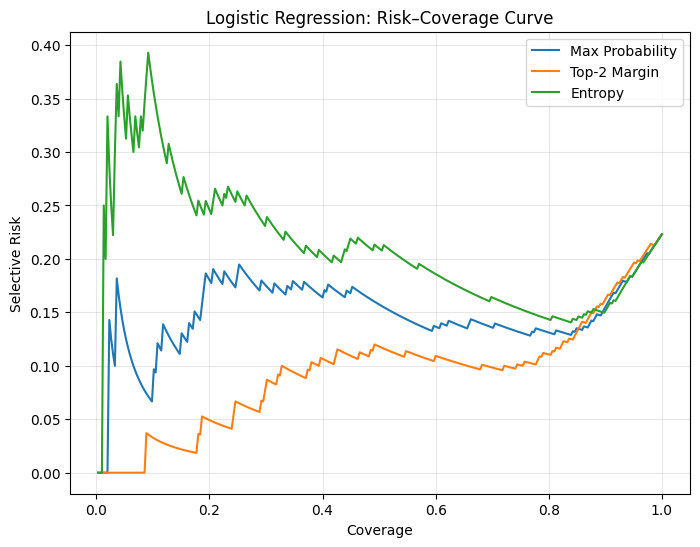

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    rc_conf["coverage"],
    rc_conf["risk"],
    label="Max Probability"
)

plt.plot(
    rc_margin["coverage"],
    rc_margin["risk"],
    label="Top-2 Margin"
)

plt.plot(
    rc_entropy["coverage"],
    rc_entropy["risk"],
    label="Entropy"
)

plt.xlabel("Coverage")
plt.ylabel("Selective Risk")
plt.title("Logistic Regression: Risk–Coverage Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [24]:
def operating_points(rc_df, targets=(1.0, 0.9, 0.8, 0.7, 0.5)):

    rows = []

    for target in targets:

        idx = np.abs(
            rc_df["coverage"].values - target
        ).argmin()

        row = rc_df.iloc[idx]

        rows.append({
            "Coverage": row["coverage"],
            "Abstention Rate": 1 - row["coverage"],
            "Selective Accuracy": row["selective_accuracy"],
            "Selective Risk": row["risk"]
        })

    return pd.DataFrame(rows)


print("MAXIMUM PROBABILITY")
display(operating_points(rc_conf))

print("TOP-2 MARGIN")
display(operating_points(rc_margin))

print("ENTROPY")
display(operating_points(rc_entropy))

MAXIMUM PROBABILITY


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.777049,0.222951
1,0.898361,0.101639,0.846715,0.153285
2,0.800000,0.200000,0.868852,0.131148
3,0.698361,0.301639,0.863850,0.136150
4,0.498361,0.501639,0.842105,0.157895


TOP-2 MARGIN


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.777049,0.222951
1,0.898361,0.101639,0.839416,0.160584
2,0.800000,0.200000,0.889344,0.110656
3,0.698361,0.301639,0.901408,0.098592
4,0.498361,0.501639,0.881579,0.118421


ENTROPY


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.777049,0.222951
1,0.898361,0.101639,0.850365,0.149635
2,0.800000,0.200000,0.856557,0.143443
3,0.698361,0.301639,0.835681,0.164319
4,0.498361,0.501639,0.789474,0.210526


In [25]:
from sklearn.metrics import log_loss
import numpy as np
import pandas as pd

def multiclass_brier_score(y_true, probs, classes):
    class_to_idx = {c: i for i, c in enumerate(classes)}

    y_onehot = np.zeros_like(probs)

    for i, label in enumerate(y_true):
        y_onehot[i, class_to_idx[label]] = 1

    return np.mean(
        np.sum((probs - y_onehot) ** 2, axis=1)
    )


def expected_calibration_error(y_true, pred, confidence, n_bins=10):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    confidence = np.asarray(confidence)

    correct = (y_true == pred).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    rows = []

    for i in range(n_bins):
        lower = bins[i]
        upper = bins[i + 1]

        if i == n_bins - 1:
            mask = (confidence >= lower) & (confidence <= upper)
        else:
            mask = (confidence >= lower) & (confidence < upper)

        n = mask.sum()

        if n == 0:
            continue

        bin_acc = correct[mask].mean()
        bin_conf = confidence[mask].mean()
        weight = n / len(confidence)

        ece += weight * abs(bin_acc - bin_conf)

        rows.append({
            "bin_lower": lower,
            "bin_upper": upper,
            "n": n,
            "accuracy": bin_acc,
            "mean_confidence": bin_conf,
            "gap": bin_acc - bin_conf
        })

    return ece, pd.DataFrame(rows)


ece_lr, calibration_table_lr = expected_calibration_error(
    y_test_clean.values,
    pred,
    confidence,
    n_bins=10
)

brier_lr = multiclass_brier_score(
    y_test_clean.values,
    probs,
    lr.classes_
)

nll_lr = log_loss(
    y_test_clean.values,
    probs,
    labels=lr.classes_
)

print(f"ECE   : {ece_lr:.4f}")
print(f"Brier : {brier_lr:.4f}")
print(f"NLL   : {nll_lr:.4f}")

display(calibration_table_lr)

ECE   : 0.5547
Brier : 0.6814
NLL   : 1.7771


,bin_lower,bin_upper,n,accuracy,mean_confidence,gap
0,0.0,0.1,30,0.166667,0.075151,0.091516
1,0.1,0.2,122,0.844262,0.162817,0.681445
2,0.2,0.3,90,0.866667,0.240215,0.626452
3,0.3,0.4,45,0.777778,0.340769,0.437009
4,0.4,0.5,13,0.846154,0.440881,0.405273
5,0.5,0.6,3,1.000000,0.554295,0.445705
6,0.6,0.7,2,1.000000,0.670996,0.329004


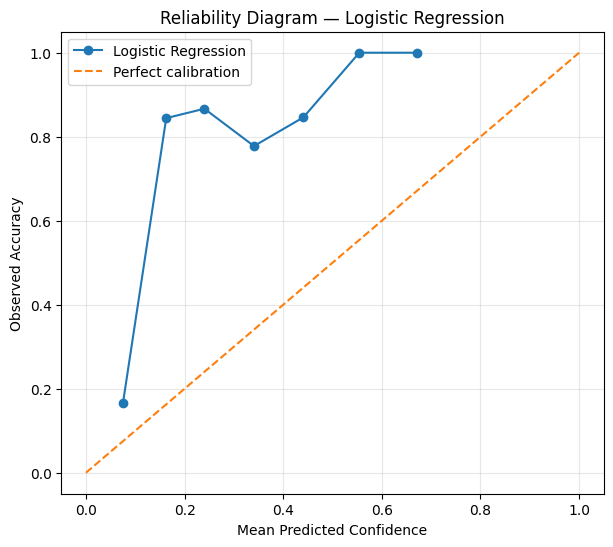

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    calibration_table_lr["mean_confidence"],
    calibration_table_lr["accuracy"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Observed Accuracy")
plt.title("Reliability Diagram — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [27]:
# ============================================================
# EXPERIMENT 2
# Logistic Regression under realistic input perturbations
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd


def evaluate_lr_condition(name, eval_df, model, vectorizer):

    X = eval_df["text"].astype(str)
    y = eval_df["label"].astype(str)

    X_vec = vectorizer.transform(X)

    pred = model.predict(X_vec)
    probs = model.predict_proba(X_vec)

    sorted_probs = np.sort(probs, axis=1)

    confidence = sorted_probs[:, -1]
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    entropy = -np.sum(
        probs * np.log(probs + 1e-12),
        axis=1
    )

    correct = pred == y.values

    results = pd.DataFrame({
        "condition": name,
        "text": X.values,
        "true_label": y.values,
        "predicted_label": pred,
        "correct": correct,
        "confidence": confidence,
        "margin": margin,
        "entropy": entropy
    })

    metrics = {
        "condition": name,
        "n": len(y),

        "accuracy":
            accuracy_score(y, pred),

        "macro_f1":
            f1_score(y, pred, average="macro", zero_division=0),

        "weighted_f1":
            f1_score(y, pred, average="weighted", zero_division=0),

        "mean_confidence":
            confidence.mean(),

        "mean_margin":
            margin.mean(),

        "mean_entropy":
            entropy.mean()
    }

    # AUROC only if both correct and incorrect predictions exist
    if len(np.unique(correct)) == 2:

        metrics["auroc_confidence"] = roc_auc_score(
            correct.astype(int),
            confidence
        )

        metrics["auroc_margin"] = roc_auc_score(
            correct.astype(int),
            margin
        )

        metrics["auroc_entropy"] = roc_auc_score(
            correct.astype(int),
            -entropy
        )

    else:

        metrics["auroc_confidence"] = np.nan
        metrics["auroc_margin"] = np.nan
        metrics["auroc_entropy"] = np.nan

    return results, metrics

In [28]:
lr_typo_results, lr_typo_metrics = evaluate_lr_condition(
    "Typo",
    typo_eval,
    lr,
    tfidf
)

lr_abbrev_results, lr_abbrev_metrics = evaluate_lr_condition(
    "Abbreviation",
    abbrev_eval,
    lr,
    tfidf
)

lr_short_results, lr_short_metrics = evaluate_lr_condition(
    "Shortened",
    short_eval,
    lr,
    tfidf
)

perturbed_summary = pd.DataFrame([
    lr_typo_metrics,
    lr_abbrev_metrics,
    lr_short_metrics
])

display(
    perturbed_summary.round(4)
)

,condition,n,accuracy,macro_f1,weighted_f1,mean_confidence,mean_margin,mean_entropy,auroc_confidence,auroc_margin,auroc_entropy
0,Typo,303,0.7393,0.4426,0.7511,0.1808,0.1021,3.1763,0.7843,0.7836,0.7029
1,Abbreviation,106,0.3396,0.3571,0.3352,0.1645,0.0846,3.1717,0.7278,0.7758,0.6659
2,Shortened,116,0.4828,0.5018,0.4832,0.1970,0.0976,3.0528,0.5568,0.6744,0.4893


In [29]:
lr_clean_typo_results, lr_clean_typo_metrics = evaluate_lr_condition(
    "Clean matched — Typo",
    clean_typo,
    lr,
    tfidf
)

lr_clean_abbrev_results, lr_clean_abbrev_metrics = evaluate_lr_condition(
    "Clean matched — Abbreviation",
    clean_abbrev,
    lr,
    tfidf
)

lr_clean_short_results, lr_clean_short_metrics = evaluate_lr_condition(
    "Clean matched — Shortened",
    clean_short,
    lr,
    tfidf
)

matched_summary = pd.DataFrame([
    lr_clean_typo_metrics,
    lr_typo_metrics,

    lr_clean_abbrev_metrics,
    lr_abbrev_metrics,

    lr_clean_short_metrics,
    lr_short_metrics
])

display(
    matched_summary.round(4)
)

,condition,n,accuracy,macro_f1,weighted_f1,mean_confidence,mean_margin,mean_entropy,auroc_confidence,auroc_margin,auroc_entropy
0,Clean matched — Typo,303,0.7756,0.5373,0.7928,0.2221,0.1449,3.0889,0.6977,0.7937,0.6080
1,Typo,303,0.7393,0.4426,0.7511,0.1808,0.1021,3.1763,0.7843,0.7836,0.7029
2,Clean matched — Abbreviation,106,0.4057,0.4549,0.3811,0.2045,0.1111,3.0638,0.6530,0.6925,0.6139
3,Abbreviation,106,0.3396,0.3571,0.3352,0.1645,0.0846,3.1717,0.7278,0.7758,0.6659
4,Clean matched — Shortened,116,0.4397,0.4802,0.4115,0.2021,0.1107,3.0754,0.6531,0.6974,0.6084
5,Shortened,116,0.4828,0.5018,0.4832,0.1970,0.0976,3.0528,0.5568,0.6744,0.4893


In [30]:
comparison_rows = []

pairs = [
    (
        "Typo",
        lr_clean_typo_metrics,
        lr_typo_metrics
    ),
    (
        "Abbreviation",
        lr_clean_abbrev_metrics,
        lr_abbrev_metrics
    ),
    (
        "Shortened",
        lr_clean_short_metrics,
        lr_short_metrics
    )
]

for condition, clean_m, pert_m in pairs:

    comparison_rows.append({
        "condition": condition,
        "n": clean_m["n"],

        "clean_accuracy":
            clean_m["accuracy"],

        "perturbed_accuracy":
            pert_m["accuracy"],

        "accuracy_drop":
            clean_m["accuracy"] -
            pert_m["accuracy"],

        "clean_macro_f1":
            clean_m["macro_f1"],

        "perturbed_macro_f1":
            pert_m["macro_f1"],

        "macro_f1_drop":
            clean_m["macro_f1"] -
            pert_m["macro_f1"],

        "clean_margin":
            clean_m["mean_margin"],

        "perturbed_margin":
            pert_m["mean_margin"],

        "margin_change":
            pert_m["mean_margin"] -
            clean_m["mean_margin"],

        "clean_entropy":
            clean_m["mean_entropy"],

        "perturbed_entropy":
            pert_m["mean_entropy"],

        "entropy_change":
            pert_m["mean_entropy"] -
            clean_m["mean_entropy"]
    })


degradation_df = pd.DataFrame(comparison_rows)

display(
    degradation_df.round(4)
)

,condition,n,clean_accuracy,perturbed_accuracy,accuracy_drop,clean_macro_f1,perturbed_macro_f1,macro_f1_drop,clean_margin,perturbed_margin,margin_change,clean_entropy,perturbed_entropy,entropy_change
0,Typo,303,0.7756,0.7393,0.0363,0.5373,0.4426,0.0947,0.1449,0.1021,-0.0427,3.0889,3.1763,0.0874
1,Abbreviation,106,0.4057,0.3396,0.0660,0.4549,0.3571,0.0978,0.1111,0.0846,-0.0265,3.0638,3.1717,0.1079
2,Shortened,116,0.4397,0.4828,-0.0431,0.4802,0.5018,-0.0217,0.1107,0.0976,-0.0131,3.0754,3.0528,-0.0226


In [31]:
comparison_rows = []

pairs = [
    (
        "Typo",
        lr_clean_typo_metrics,
        lr_typo_metrics
    ),
    (
        "Abbreviation",
        lr_clean_abbrev_metrics,
        lr_abbrev_metrics
    ),
    (
        "Shortened",
        lr_clean_short_metrics,
        lr_short_metrics
    )
]

for condition, clean_m, pert_m in pairs:

    comparison_rows.append({
        "condition": condition,
        "n": clean_m["n"],

        "clean_accuracy":
            clean_m["accuracy"],

        "perturbed_accuracy":
            pert_m["accuracy"],

        "accuracy_drop":
            clean_m["accuracy"] -
            pert_m["accuracy"],

        "clean_macro_f1":
            clean_m["macro_f1"],

        "perturbed_macro_f1":
            pert_m["macro_f1"],

        "macro_f1_drop":
            clean_m["macro_f1"] -
            pert_m["macro_f1"],

        "clean_margin":
            clean_m["mean_margin"],

        "perturbed_margin":
            pert_m["mean_margin"],

        "margin_change":
            pert_m["mean_margin"] -
            clean_m["mean_margin"],

        "clean_entropy":
            clean_m["mean_entropy"],

        "perturbed_entropy":
            pert_m["mean_entropy"],

        "entropy_change":
            pert_m["mean_entropy"] -
            clean_m["mean_entropy"]
    })


degradation_df = pd.DataFrame(comparison_rows)

display(
    degradation_df.round(4)
)

,condition,n,clean_accuracy,perturbed_accuracy,accuracy_drop,clean_macro_f1,perturbed_macro_f1,macro_f1_drop,clean_margin,perturbed_margin,margin_change,clean_entropy,perturbed_entropy,entropy_change
0,Typo,303,0.7756,0.7393,0.0363,0.5373,0.4426,0.0947,0.1449,0.1021,-0.0427,3.0889,3.1763,0.0874
1,Abbreviation,106,0.4057,0.3396,0.0660,0.4549,0.3571,0.0978,0.1111,0.0846,-0.0265,3.0638,3.1717,0.1079
2,Shortened,116,0.4397,0.4828,-0.0431,0.4802,0.5018,-0.0217,0.1107,0.0976,-0.0131,3.0754,3.0528,-0.0226


In [34]:
from scipy.stats import binomtest, wilcoxon
import numpy as np
import pandas as pd

def paired_condition_analysis(name, clean_results, pert_results):

    clean_correct = clean_results["correct"].to_numpy().astype(bool)
    pert_correct = pert_results["correct"].to_numpy().astype(bool)

    assert len(clean_correct) == len(pert_correct)

    assert np.array_equal(
        clean_results["true_label"].to_numpy(),
        pert_results["true_label"].to_numpy()
    )

    # Prediction flip categories
    both_correct = np.sum(clean_correct & pert_correct)

    harmed = np.sum(
        clean_correct & ~pert_correct
    )  # correct -> wrong

    helped = np.sum(
        ~clean_correct & pert_correct
    )  # wrong -> correct

    both_wrong = np.sum(
        ~clean_correct & ~pert_correct
    )

    discordant = harmed + helped

    # Exact McNemar equivalent using binomial test
    if discordant > 0:
        mcnemar_p = binomtest(
            min(harmed, helped),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue
    else:
        mcnemar_p = np.nan

    # Paired uncertainty changes
    confidence_change = (
        pert_results["confidence"].to_numpy()
        - clean_results["confidence"].to_numpy()
    )

    margin_change = (
        pert_results["margin"].to_numpy()
        - clean_results["margin"].to_numpy()
    )

    entropy_change = (
        pert_results["entropy"].to_numpy()
        - clean_results["entropy"].to_numpy()
    )

    # Wilcoxon paired tests
    try:
        confidence_p = wilcoxon(confidence_change).pvalue
    except ValueError:
        confidence_p = np.nan

    try:
        margin_p = wilcoxon(margin_change).pvalue
    except ValueError:
        margin_p = np.nan

    try:
        entropy_p = wilcoxon(entropy_change).pvalue
    except ValueError:
        entropy_p = np.nan

    return {
        "condition": name,
        "n": len(clean_correct),

        "both_correct": both_correct,
        "harmed_correct_to_wrong": harmed,
        "helped_wrong_to_correct": helped,
        "both_wrong": both_wrong,

        "accuracy_change":
            pert_correct.mean() - clean_correct.mean(),

        "mcnemar_p":
            mcnemar_p,

        "mean_confidence_change":
            confidence_change.mean(),

        "confidence_p":
            confidence_p,

        "mean_margin_change":
            margin_change.mean(),

        "margin_p":
            margin_p,

        "mean_entropy_change":
            entropy_change.mean(),

        "entropy_p":
            entropy_p
    }

print("paired_condition_analysis function loaded successfully.")

paired_condition_analysis function loaded successfully.


In [35]:
paired_summary = pd.DataFrame([
    paired_condition_analysis(
        "Typo",
        lr_clean_typo_results,
        lr_typo_results
    ),

    paired_condition_analysis(
        "Abbreviation",
        lr_clean_abbrev_results,
        lr_abbrev_results
    ),

    paired_condition_analysis(
        "Shortened",
        lr_clean_short_results,
        lr_short_results
    )
])

display(paired_summary.round(4))

,condition,n,both_correct,harmed_correct_to_wrong,helped_wrong_to_correct,both_wrong,accuracy_change,mcnemar_p,mean_confidence_change,confidence_p,mean_margin_change,margin_p,mean_entropy_change,entropy_p
0,Typo,303,216,19,8,60,-0.0363,0.0522,-0.0413,0.0000,-0.0427,0.0000,0.0874,0.0000
1,Abbreviation,106,31,12,5,58,-0.0660,0.1435,-0.0400,0.0005,-0.0265,0.0042,0.1079,0.0029
2,Shortened,116,44,7,12,53,0.0431,0.3593,-0.0050,0.5555,-0.0131,0.1419,-0.0226,0.1752


In [36]:
# ============================================================
# SHORTENING FLIP ANALYSIS
# ============================================================

short_flip_analysis = pd.DataFrame({
    "original_text":
        clean_short["text"].values,

    "shortened_text":
        short_eval["text"].values,

    "true_label":
        lr_clean_short_results["true_label"].values,

    "clean_prediction":
        lr_clean_short_results["predicted_label"].values,

    "short_prediction":
        lr_short_results["predicted_label"].values,

    "clean_correct":
        lr_clean_short_results["correct"].values,

    "short_correct":
        lr_short_results["correct"].values,

    "clean_margin":
        lr_clean_short_results["margin"].values,

    "short_margin":
        lr_short_results["margin"].values
})

In [38]:
helped = short_flip_analysis[
    (~short_flip_analysis["clean_correct"])
    &
    (short_flip_analysis["short_correct"])
]

print("Wrong → Correct after shortening:", len(helped))

display(
    helped[
        [
            "original_text",
            "shortened_text",
            "true_label",
            "clean_prediction",
            "short_prediction",
            "clean_margin",
            "short_margin"
        ]
    ]
)

Wrong → Correct after shortening: 12


,original_text,shortened_text,true_label,clean_prediction,short_prediction,clean_margin,short_margin
1,Hi! Can I get some assistance?,Hi! get some assistance?,greeting,budget and saving tips,greeting,0.001059,0.007771
25,What was my total savings for January 2016?,total savings January 2016?,monthly savings,yearly savings,monthly savings,0.027693,0.059124
26,Can you tell me my total savings for February ...,you total savings February 2017?,monthly savings,yearly savings,monthly savings,0.066885,0.025990
42,Can you tell me my total income from other sou...,you total income from other sources 2017?,yearly income (category),monthly income (category),yearly income (category),0.124997,0.043289
66,Tips for effective saving?,Tips effective saving?,budget and saving tips,Retirement Planning tips,budget and saving tips,0.003945,0.002241
84,What did I pay for health in January?,pay health in January?,expense,expense overview,expense,0.034143,0.008809
85,I need to see my total spending for last year.,see total spending last year.,expense,monthly budget,expense,0.004565,0.000213
88,Show me my expenditure for the past six months.,expenditure past six months.,expense,monthly budget,expense,0.023009,0.011785
93,What did tithes cost me this year?,tithes cost this year?,expense,expense overview,expense,0.025211,0.038194
94,What were my leisure costs in August?,leisure costs in August?,expense,savings overview,expense,0.001059,0.007386


In [39]:
harmed = short_flip_analysis[
    (short_flip_analysis["clean_correct"])
    &
    (~short_flip_analysis["short_correct"])
]

print("Correct → Wrong after shortening:", len(harmed))

display(
    harmed[
        [
            "original_text",
            "shortened_text",
            "true_label",
            "clean_prediction",
            "short_prediction",
            "clean_margin",
            "short_margin"
        ]
    ]
)

Correct → Wrong after shortening: 7


,original_text,shortened_text,true_label,clean_prediction,short_prediction,clean_margin,short_margin
2,Life's treating me well,Life's treating well,current mood,current mood,concern,0.069849,0.009850
14,What was the savings for liquid cash in April ...,savings liquid cash in April 2019?,savings overview,savings overview,savings,0.060529,0.002853
15,How much was saved on liquid cash in August 2017?,How much saved on liquid cash in August 2017?,savings overview,savings overview,savings,0.036325,0.005968
33,What was my total savings for 2016?,total savings 2016?,yearly savings,yearly savings,monthly savings,0.091188,0.022570
34,Tell me my total savings for 2020.,total savings 2020.,yearly savings,yearly savings,monthly savings,0.100339,0.026032
36,Tell me my total income for 2020.,total income 2020.,yearly income,yearly income,monthly income,0.017494,0.093891
69,Can I find a way to decrease the interest on w...,find way decrease interest on owe?,Guidance for Managing Debts,Guidance for Managing Debts,yearly expense (category),0.055592,0.005627


In [40]:
# ============================================================
# EXPERIMENT 3 — CALIBRATED LINEAR SVM
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score

base_svm = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

svm = CalibratedClassifierCV(
    base_svm,
    method="sigmoid",
    cv=3
)

svm.fit(X_train_vec, y_train)

svm_pred = svm.predict(X_test_vec)
svm_probs = svm.predict_proba(X_test_vec)

print(
    "Clean Accuracy:",
    accuracy_score(y_test_clean, svm_pred)
)

print(
    "Clean Macro F1:",
    f1_score(
        y_test_clean,
        svm_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Clean Weighted F1:",
    f1_score(
        y_test_clean,
        svm_pred,
        average="weighted",
        zero_division=0
    )
)

Clean Accuracy: 0.8163934426229508
Clean Macro F1: 0.5650911772127342
Clean Weighted F1: 0.8166219472742519


In [41]:
# ============================================================
# SVM — UNCERTAINTY ANALYSIS ON CLEAN TEST SET
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Sort probabilities
svm_sorted_probs = np.sort(svm_probs, axis=1)

svm_confidence = svm_sorted_probs[:, -1]
svm_margin = svm_sorted_probs[:, -1] - svm_sorted_probs[:, -2]

svm_entropy = -np.sum(
    svm_probs * np.log(svm_probs + 1e-12),
    axis=1
)

svm_correct = svm_pred == y_test_clean.values

svm_results = pd.DataFrame({
    "text": test_df["text"].values,
    "true_label": y_test_clean.values,
    "predicted_label": svm_pred,
    "correct": svm_correct,
    "confidence": svm_confidence,
    "margin": svm_margin,
    "entropy": svm_entropy
})

print("Number correct:", svm_correct.sum())
print("Number wrong  :", (~svm_correct).sum())

print("\nMEAN CONFIDENCE")
print(svm_results.groupby("correct")["confidence"].mean())

print("\nMEAN TOP-2 MARGIN")
print(svm_results.groupby("correct")["margin"].mean())

print("\nMEAN ENTROPY")
print(svm_results.groupby("correct")["entropy"].mean())

# Error-detection AUROC
svm_correct_binary = svm_correct.astype(int)

svm_auc_confidence = roc_auc_score(
    svm_correct_binary,
    svm_confidence
)

svm_auc_margin = roc_auc_score(
    svm_correct_binary,
    svm_margin
)

svm_auc_entropy = roc_auc_score(
    svm_correct_binary,
    -svm_entropy
)

print("\nAUROC FOR IDENTIFYING CORRECT PREDICTIONS")
print("------------------------------------------")
print(f"Maximum probability : {svm_auc_confidence:.4f}")
print(f"Top-2 margin        : {svm_auc_margin:.4f}")
print(f"Negative entropy    : {svm_auc_entropy:.4f}")

Number correct: 249
Number wrong  : 56

MEAN CONFIDENCE
correct
False    0.409246
True     0.764766
Name: confidence, dtype: float64

MEAN TOP-2 MARGIN
correct
False    0.202953
True     0.702484
Name: margin, dtype: float64

MEAN ENTROPY
correct
False    2.059446
True     1.133001
Name: entropy, dtype: float64

AUROC FOR IDENTIFYING CORRECT PREDICTIONS
------------------------------------------
Maximum probability : 0.9216
Top-2 margin        : 0.9243
Negative entropy    : 0.9004


In [42]:
# ============================================================
# SVM — RISK-COVERAGE / AURC
# ============================================================

svm_rc_conf = risk_coverage_curve(
    svm_results["correct"],
    svm_results["confidence"]
)

svm_rc_margin = risk_coverage_curve(
    svm_results["correct"],
    svm_results["margin"]
)

svm_rc_entropy = risk_coverage_curve(
    svm_results["correct"],
    -svm_results["entropy"]
)

print("SVM AURC")
print("----------------------------")
print(f"Maximum probability : {aurc(svm_rc_conf):.4f}")
print(f"Top-2 margin        : {aurc(svm_rc_margin):.4f}")
print(f"Entropy             : {aurc(svm_rc_entropy):.4f}")

SVM AURC
----------------------------
Maximum probability : 0.0325
Top-2 margin        : 0.0319
Entropy             : 0.0366


In [43]:
print("SVM — MAXIMUM PROBABILITY")
display(operating_points(svm_rc_conf))

print("SVM — TOP-2 MARGIN")
display(operating_points(svm_rc_margin))

print("SVM — ENTROPY")
display(operating_points(svm_rc_entropy))

SVM — MAXIMUM PROBABILITY


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.816393,0.183607
1,0.898361,0.101639,0.872263,0.127737
2,0.800000,0.200000,0.926230,0.073770
3,0.698361,0.301639,0.971831,0.028169
4,0.498361,0.501639,1.000000,0.000000


SVM — TOP-2 MARGIN


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.816393,0.183607
1,0.898361,0.101639,0.864964,0.135036
2,0.800000,0.200000,0.926230,0.073770
3,0.698361,0.301639,0.976526,0.023474
4,0.498361,0.501639,1.000000,0.000000


SVM — ENTROPY


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.816393,0.183607
1,0.898361,0.101639,0.868613,0.131387
2,0.800000,0.200000,0.901639,0.098361
3,0.698361,0.301639,0.953052,0.046948
4,0.498361,0.501639,1.000000,0.000000


In [44]:
# ============================================================
# SVM — CALIBRATION ANALYSIS
# ============================================================

svm_ece, svm_calibration_table = expected_calibration_error(
    y_test_clean.values,
    svm_pred,
    svm_confidence,
    n_bins=10
)

svm_brier = multiclass_brier_score(
    y_test_clean.values,
    svm_probs,
    svm.classes_
)

svm_nll = log_loss(
    y_test_clean.values,
    svm_probs,
    labels=svm.classes_
)

print(f"SVM ECE   : {svm_ece:.4f}")
print(f"SVM Brier : {svm_brier:.4f}")
print(f"SVM NLL   : {svm_nll:.4f}")

display(svm_calibration_table)

SVM ECE   : 0.1263
SVM Brier : 0.2552
SVM NLL   : 0.6750


,bin_lower,bin_upper,n,accuracy,mean_confidence,gap
0,0.1,0.2,7,0.428571,0.158091,0.270480
1,0.2,0.3,17,0.176471,0.260916,-0.084445
2,0.3,0.4,15,0.533333,0.350436,0.182897
3,0.4,0.5,26,0.461538,0.456067,0.005471
4,0.5,0.6,28,0.607143,0.533483,0.073660
5,0.6,0.7,15,0.733333,0.643261,0.090072
6,0.7,0.8,12,0.833333,0.751045,0.082289
7,0.8,0.9,185,1.000000,0.849129,0.150871


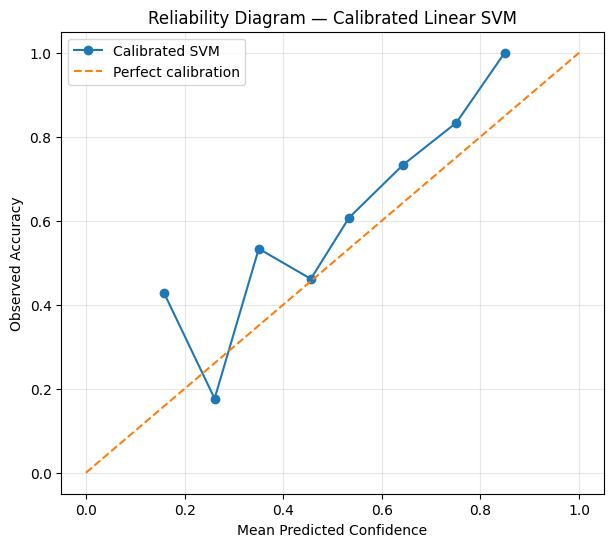

In [45]:
plt.figure(figsize=(7, 6))

plt.plot(
    svm_calibration_table["mean_confidence"],
    svm_calibration_table["accuracy"],
    marker="o",
    label="Calibrated SVM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Observed Accuracy")
plt.title("Reliability Diagram — Calibrated Linear SVM")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [46]:
calibration_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Calibrated Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test_clean, pred),
        accuracy_score(y_test_clean, svm_pred)
    ],

    "ECE": [
        ece_lr,
        svm_ece
    ],

    "Brier": [
        brier_lr,
        svm_brier
    ],

    "NLL": [
        nll_lr,
        svm_nll
    ],

    "Margin AUROC": [
        auc_margin,
        svm_auc_margin
    ],

    "Margin AURC": [
        aurc(rc_margin),
        aurc(svm_rc_margin)
    ]
})

display(calibration_comparison.round(4))

,Model,Accuracy,ECE,Brier,NLL,Margin AUROC,Margin AURC
0,Logistic Regression,0.7770,0.5547,0.6814,1.7771,0.7950,0.0935
1,Calibrated Linear SVM,0.8164,0.1263,0.2552,0.6750,0.9243,0.0319


In [47]:
svm_typo_results, svm_typo_metrics = evaluate_lr_condition(
    "Typo",
    typo_eval,
    svm,
    tfidf
)

svm_abbrev_results, svm_abbrev_metrics = evaluate_lr_condition(
    "Abbreviation",
    abbrev_eval,
    svm,
    tfidf
)

svm_short_results, svm_short_metrics = evaluate_lr_condition(
    "Shortened",
    short_eval,
    svm,
    tfidf
)


svm_clean_typo_results, svm_clean_typo_metrics = evaluate_lr_condition(
    "Clean matched — Typo",
    clean_typo,
    svm,
    tfidf
)

svm_clean_abbrev_results, svm_clean_abbrev_metrics = evaluate_lr_condition(
    "Clean matched — Abbreviation",
    clean_abbrev,
    svm,
    tfidf
)

svm_clean_short_results, svm_clean_short_metrics = evaluate_lr_condition(
    "Clean matched — Shortened",
    clean_short,
    svm,
    tfidf
)

In [48]:
svm_matched_summary = pd.DataFrame([
    svm_clean_typo_metrics,
    svm_typo_metrics,

    svm_clean_abbrev_metrics,
    svm_abbrev_metrics,

    svm_clean_short_metrics,
    svm_short_metrics
])

display(svm_matched_summary.round(4))

,condition,n,accuracy,macro_f1,weighted_f1,mean_confidence,mean_margin,mean_entropy,auroc_confidence,auroc_margin,auroc_entropy
0,Clean matched — Typo,303,0.8152,0.5626,0.8154,0.6987,0.6096,1.3052,0.9210,0.9237,0.8996
1,Typo,303,0.7492,0.4639,0.7510,0.6145,0.4895,1.5656,0.9348,0.9068,0.9102
2,Clean matched — Abbreviation,106,0.5094,0.5021,0.5036,0.4762,0.2919,1.9067,0.7133,0.7247,0.6400
3,Abbreviation,106,0.4057,0.3877,0.4007,0.4143,0.2529,2.1364,0.8667,0.8272,0.8295
4,Clean matched — Shortened,116,0.5431,0.5425,0.5318,0.4800,0.3022,1.9096,0.7182,0.7338,0.6376
5,Shortened,116,0.5431,0.5320,0.5300,0.4846,0.3097,1.8413,0.6358,0.6158,0.6035


In [49]:
svm_paired_summary = pd.DataFrame([
    paired_condition_analysis(
        "Typo",
        svm_clean_typo_results,
        svm_typo_results
    ),

    paired_condition_analysis(
        "Abbreviation",
        svm_clean_abbrev_results,
        svm_abbrev_results
    ),

    paired_condition_analysis(
        "Shortened",
        svm_clean_short_results,
        svm_short_results
    )
])

display(svm_paired_summary.round(4))

,condition,n,both_correct,harmed_correct_to_wrong,helped_wrong_to_correct,both_wrong,accuracy_change,mcnemar_p,mean_confidence_change,confidence_p,mean_margin_change,margin_p,mean_entropy_change,entropy_p
0,Typo,303,219,28,8,48,-0.0660,0.0012,-0.0842,0.0000,-0.1201,0.0000,0.2604,0.0000
1,Abbreviation,106,39,15,4,48,-0.1038,0.0192,-0.0620,0.0003,-0.0390,0.0442,0.2297,0.0010
2,Shortened,116,49,14,14,39,0.0000,1.0000,0.0047,0.8332,0.0076,0.8575,-0.0683,0.1322


HILBOT V3

In [50]:
# ============================================================
# EXPERIMENT 4 — HILBOT V3 ADAPTED HYBRID
# Raw-text selective-prediction protocol
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate
)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [54]:
from pathlib import Path

GLOVE_PATH = "/content/drive/MyDrive/Hilbot/glove.6B.200d.txt"

print("GloVe path:", GLOVE_PATH)
print("Exists:", Path(GLOVE_PATH).exists())

assert Path(GLOVE_PATH).exists(), "GloVe file not found."

GloVe path: /content/drive/MyDrive/Hilbot/glove.6B.200d.txt
Exists: True


In [55]:
MAX_LEN = 30
EMBED_DIM = 200

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    train_df["label"].astype(str)
)

y_test_encoded = label_encoder.transform(
    test_df["label"].astype(str)
)

NUM_CLASSES = len(label_encoder.classes_)

tokenizer = Tokenizer(
    oov_token="<OOV>"
)

# Fit ONLY on training text
tokenizer.fit_on_texts(
    train_df["text"].astype(str)
)

train_sequences = tokenizer.texts_to_sequences(
    train_df["text"].astype(str)
)

test_sequences = tokenizer.texts_to_sequences(
    test_df["text"].astype(str)
)

X_seq_train = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_seq_test = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

VOCAB_SIZE = len(tokenizer.word_index) + 1

print("Vocabulary size:", VOCAB_SIZE)
print("Train sequence shape:", X_seq_train.shape)
print("Test sequence shape :", X_seq_test.shape)
print("Number of classes   :", NUM_CLASSES)

Vocabulary size: 595
Train sequence shape: (1220, 30)
Test sequence shape : (305, 30)
Number of classes   : 33


In [56]:
X_tfidf_train = X_train_vec.toarray().astype("float32")
X_tfidf_test = X_test_vec.toarray().astype("float32")

TFIDF_DIM = X_tfidf_train.shape[1]

print("TF-IDF dimension:", TFIDF_DIM)

TF-IDF dimension: 2589


In [57]:
embeddings_index = {}

with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        values = line.rstrip().split(" ")

        word = values[0]
        vector = np.asarray(
            values[1:],
            dtype="float32"
        )

        if len(vector) == EMBED_DIM:
            embeddings_index[word] = vector

print("Loaded GloVe vectors:", len(embeddings_index))

Loaded GloVe vectors: 400000


In [58]:
rng = np.random.default_rng(SEED)

embedding_matrix = rng.normal(
    loc=0.0,
    scale=0.6,
    size=(VOCAB_SIZE, EMBED_DIM)
).astype("float32")

# Padding token = zero vector
embedding_matrix[0] = np.zeros(
    EMBED_DIM,
    dtype="float32"
)

found = 0

for word, index in tokenizer.word_index.items():

    vector = embeddings_index.get(word)

    if vector is not None:
        embedding_matrix[index] = vector
        found += 1

print("Vocabulary size :", VOCAB_SIZE)
print("Found in GloVe :", found)
print(
    "Coverage       :",
    round(100 * found / (VOCAB_SIZE - 1), 2),
    "%"
)

Vocabulary size : 595
Found in GloVe : 569
Coverage       : 95.79 %


In [59]:
indices = np.arange(len(train_df))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_encoded
)

seq_train = X_seq_train[train_idx]
seq_val = X_seq_train[val_idx]

tfidf_train = X_tfidf_train[train_idx]
tfidf_val = X_tfidf_train[val_idx]

y_h_train = y_train_encoded[train_idx]
y_h_val = y_train_encoded[val_idx]

print("Hybrid training:", len(train_idx))
print("Validation     :", len(val_idx))

Hybrid training: 1037
Validation     : 183


In [60]:
classes = np.unique(y_h_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_h_train
)

hilbot_class_weights = {
    int(c): float(w)
    for c, w in zip(classes, weights)
}

print("Class weights:", len(hilbot_class_weights))

Class weights: 33


In [61]:
# -------------------------
# GloVe-CNN branch
# -------------------------

seq_input = Input(
    shape=(MAX_LEN,),
    name="sequence_input"
)

x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    weights=[embedding_matrix],
    trainable=False,
    name="frozen_glove"
)(seq_input)

x = Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    padding="same",
    name="glove_conv"
)(x)

x = GlobalMaxPooling1D(
    name="glove_global_pool"
)(x)


# -------------------------
# TF-IDF branch
# -------------------------

tfidf_input = Input(
    shape=(TFIDF_DIM,),
    name="tfidf_input"
)

t = Dense(
    256,
    activation="relu",
    name="tfidf_dense_256"
)(tfidf_input)

t = Dense(
    128,
    activation="relu",
    name="tfidf_dense_128"
)(t)


# -------------------------
# Late fusion
# -------------------------

fusion = Concatenate(
    name="late_fusion"
)([x, t])

fusion = Dense(
    128,
    activation="relu",
    name="fusion_dense"
)(fusion)

fusion = Dropout(
    0.25,
    name="fusion_dropout"
)(fusion)

output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="intent_output"
)(fusion)

hilbot_v3 = Model(
    inputs=[seq_input, tfidf_input],
    outputs=output,
    name="Hilbot_V3_Selective"
)

hilbot_v3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hilbot_v3.summary()

Model: "Hilbot_V3_Selective"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frozen_glove        │ (None, 30, 200)   │    119,000 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_input         │ (None, 2589)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_conv (Conv1D) │ (None, 30, 64)    │     38,464 │ frozen_glove[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_dense_256     │ (None, 256)       │    663,040 │ tfidf_input[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_global_pool   │ (None, 64)        │          0 │ glove_conv[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_dense_128     │ (None, 128)       │     32,896 │ tfidf_dense_256[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion         │ (None, 192)       │          0 │ glove_global_poo… │
│ (Concatenate)       │                   │            │ tfidf_dense_128[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 128)       │     24,704 │ late_fusion[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 128)       │          0 │ fusion_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ intent_output       │ (None, 33)        │      4,257 │ fusion_dropout[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 882,361 (3.37 MB)

 Trainable params: 763,361 (2.91 MB)

 Non-trainable params: 119,000 (464.84 KB)

In [62]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history_hilbot = hilbot_v3.fit(
    [seq_train, tfidf_train],
    y_h_train,

    validation_data=(
        [seq_val, tfidf_val],
        y_h_val
    ),

    epochs=60,
    batch_size=32,

    class_weight=hilbot_class_weights,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.1639 - loss: 3.4216 - val_accuracy: 0.4317 - val_loss: 2.7415
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4928 - loss: 2.7430 - val_accuracy: 0.7322 - val_loss: 1.5426
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6856 - loss: 1.9064 - val_accuracy: 0.8197 - val_loss: 0.9712
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8438 - loss: 1.0372 - val_accuracy: 0.8251 - val_loss: 0.6643
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9026 - loss: 0.4877 - val_accuracy: 0.8470 - val_loss: 0.5494
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9412 - loss: 0.2560 - val_accuracy: 0.8907 - val_loss: 0.4015
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9547 - loss: 0.1621 - val_accuracy: 0.8852 - val_loss: 0.3711
Epoch 8/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9634 - loss: 0.1191 - val_accuracy: 0.9016 - v

In [63]:
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

hilbot_probs = hilbot_v3.predict(
    [X_seq_test, X_tfidf_test],
    verbose=0
)

hilbot_pred_encoded = np.argmax(
    hilbot_probs,
    axis=1
)

hilbot_pred = label_encoder.inverse_transform(
    hilbot_pred_encoded
)

hilbot_true = test_df["label"].astype(str).values

hilbot_accuracy = accuracy_score(
    hilbot_true,
    hilbot_pred
)

hilbot_macro_f1 = f1_score(
    hilbot_true,
    hilbot_pred,
    average="macro",
    zero_division=0
)

hilbot_weighted_f1 = f1_score(
    hilbot_true,
    hilbot_pred,
    average="weighted",
    zero_division=0
)

print(f"Hilbot Accuracy    : {hilbot_accuracy:.4f}")
print(f"Hilbot Macro F1    : {hilbot_macro_f1:.4f}")
print(f"Hilbot Weighted F1 : {hilbot_weighted_f1:.4f}")

Hilbot Accuracy    : 0.9148
Hilbot Macro F1    : 0.8358
Hilbot Weighted F1 : 0.9173


In [64]:
# ============================================================
# SAVE TRAINED HILBOT V3
# ============================================================

MODEL_DIR = "/content/drive/MyDrive/Hilbot chatbot (1)/Hilbot-FI"

hilbot_v3.save(
    f"{MODEL_DIR}/hilbot_v3_selective.keras"
)

print("Hilbot V3 saved.")

Hilbot V3 saved.


In [65]:
best_epoch = np.argmin(
    history_hilbot.history["val_loss"]
) + 1

best_val_loss = min(
    history_hilbot.history["val_loss"]
)

best_val_acc = history_hilbot.history[
    "val_accuracy"
][best_epoch - 1]

print("Best epoch       :", best_epoch)
print("Best val loss    :", round(best_val_loss, 4))
print("Val accuracy then:", round(best_val_acc, 4))

Best epoch       : 25
Best val loss    : 0.2088
Val accuracy then: 0.9344


In [66]:
# ============================================================
# HILBOT V3 — UNCERTAINTY ANALYSIS
# ============================================================

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

hilbot_sorted_probs = np.sort(
    hilbot_probs,
    axis=1
)

hilbot_confidence = hilbot_sorted_probs[:, -1]

hilbot_margin = (
    hilbot_sorted_probs[:, -1]
    - hilbot_sorted_probs[:, -2]
)

hilbot_entropy = -np.sum(
    hilbot_probs *
    np.log(hilbot_probs + 1e-12),
    axis=1
)

hilbot_correct = (
    hilbot_pred == hilbot_true
)

hilbot_results = pd.DataFrame({
    "text": test_df["text"].values,
    "true_label": hilbot_true,
    "predicted_label": hilbot_pred,
    "correct": hilbot_correct,
    "confidence": hilbot_confidence,
    "margin": hilbot_margin,
    "entropy": hilbot_entropy
})

print("Number correct:", hilbot_correct.sum())
print("Number wrong  :", (~hilbot_correct).sum())

print("\nMEAN CONFIDENCE")
print(
    hilbot_results
    .groupby("correct")["confidence"]
    .mean()
)

print("\nMEAN TOP-2 MARGIN")
print(
    hilbot_results
    .groupby("correct")["margin"]
    .mean()
)

print("\nMEAN ENTROPY")
print(
    hilbot_results
    .groupby("correct")["entropy"]
    .mean()
)

Number correct: 279
Number wrong  : 26

MEAN CONFIDENCE
correct
False    0.590936
True     0.956751
Name: confidence, dtype: float32

MEAN TOP-2 MARGIN
correct
False    0.390628
True     0.934829
Name: margin, dtype: float32

MEAN ENTROPY
correct
False    1.223736
True     0.147667
Name: entropy, dtype: float32


In [67]:
hilbot_correct_binary = (
    hilbot_correct.astype(int)
)

hilbot_auc_confidence = roc_auc_score(
    hilbot_correct_binary,
    hilbot_confidence
)

hilbot_auc_margin = roc_auc_score(
    hilbot_correct_binary,
    hilbot_margin
)

hilbot_auc_entropy = roc_auc_score(
    hilbot_correct_binary,
    -hilbot_entropy
)

print(
    "\nAUROC FOR IDENTIFYING CORRECT PREDICTIONS"
)
print("------------------------------------------")

print(
    f"Maximum probability : "
    f"{hilbot_auc_confidence:.4f}"
)

print(
    f"Top-2 margin        : "
    f"{hilbot_auc_margin:.4f}"
)

print(
    f"Negative entropy    : "
    f"{hilbot_auc_entropy:.4f}"
)


AUROC FOR IDENTIFYING CORRECT PREDICTIONS
------------------------------------------
Maximum probability : 0.9468
Top-2 margin        : 0.9487
Negative entropy    : 0.9440


In [68]:
hilbot_rc_conf = risk_coverage_curve(
    hilbot_results["correct"],
    hilbot_results["confidence"]
)

hilbot_rc_margin = risk_coverage_curve(
    hilbot_results["correct"],
    hilbot_results["margin"]
)

hilbot_rc_entropy = risk_coverage_curve(
    hilbot_results["correct"],
    -hilbot_results["entropy"]
)

print("HILBOT V3 AURC")
print("----------------------------")

print(
    f"Maximum probability : "
    f"{aurc(hilbot_rc_conf):.4f}"
)

print(
    f"Top-2 margin        : "
    f"{aurc(hilbot_rc_margin):.4f}"
)

print(
    f"Entropy             : "
    f"{aurc(hilbot_rc_entropy):.4f}"
)

HILBOT V3 AURC
----------------------------
Maximum probability : 0.0084
Top-2 margin        : 0.0082
Entropy             : 0.0086


In [69]:
print("HILBOT V3 — MAXIMUM PROBABILITY")
display(
    operating_points(hilbot_rc_conf)
)

print("HILBOT V3 — TOP-2 MARGIN")
display(
    operating_points(hilbot_rc_margin)
)

print("HILBOT V3 — ENTROPY")
display(
    operating_points(hilbot_rc_entropy)
)

HILBOT V3 — MAXIMUM PROBABILITY


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.914754,0.085246
1,0.898361,0.101639,0.963504,0.036496
2,0.800000,0.200000,0.991803,0.008197
3,0.698361,0.301639,1.000000,0.000000
4,0.498361,0.501639,1.000000,0.000000


HILBOT V3 — TOP-2 MARGIN


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.914754,0.085246
1,0.898361,0.101639,0.963504,0.036496
2,0.800000,0.200000,0.991803,0.008197
3,0.698361,0.301639,1.000000,0.000000
4,0.498361,0.501639,1.000000,0.000000


HILBOT V3 — ENTROPY


,Coverage,Abstention Rate,Selective Accuracy,Selective Risk
0,1.000000,0.000000,0.914754,0.085246
1,0.898361,0.101639,0.967153,0.032847
2,0.800000,0.200000,0.991803,0.008197
3,0.698361,0.301639,1.000000,0.000000
4,0.498361,0.501639,1.000000,0.000000


In [70]:
# ============================================================
# HILBOT V3 — CALIBRATION
# ============================================================

from sklearn.metrics import log_loss

hilbot_ece, hilbot_calibration_table = expected_calibration_error(
    hilbot_true,
    hilbot_pred,
    hilbot_confidence,
    n_bins=10
)

hilbot_brier = multiclass_brier_score(
    hilbot_true,
    hilbot_probs,
    label_encoder.classes_
)

hilbot_nll = log_loss(
    hilbot_true,
    hilbot_probs,
    labels=label_encoder.classes_
)

print(f"Hilbot ECE   : {hilbot_ece:.4f}")
print(f"Hilbot Brier : {hilbot_brier:.4f}")
print(f"Hilbot NLL   : {hilbot_nll:.4f}")

display(hilbot_calibration_table)

Hilbot ECE   : 0.0330
Hilbot Brier : 0.1296
Hilbot NLL   : 0.3272


,bin_lower,bin_upper,n,accuracy,mean_confidence,gap
0,0.1,0.2,2,0.000000,0.177149,-0.177149
1,0.2,0.3,2,0.500000,0.244526,0.255474
2,0.3,0.4,5,0.400000,0.335151,0.064849
3,0.4,0.5,9,0.666667,0.460301,0.206365
4,0.5,0.6,9,0.333333,0.539969,-0.206636
5,0.6,0.7,8,0.750000,0.664194,0.085806
6,0.7,0.8,7,0.714286,0.747201,-0.032915
7,0.8,0.9,13,0.615385,0.873438,-0.258054
8,0.9,1.0,250,0.992000,0.995511,-0.003511


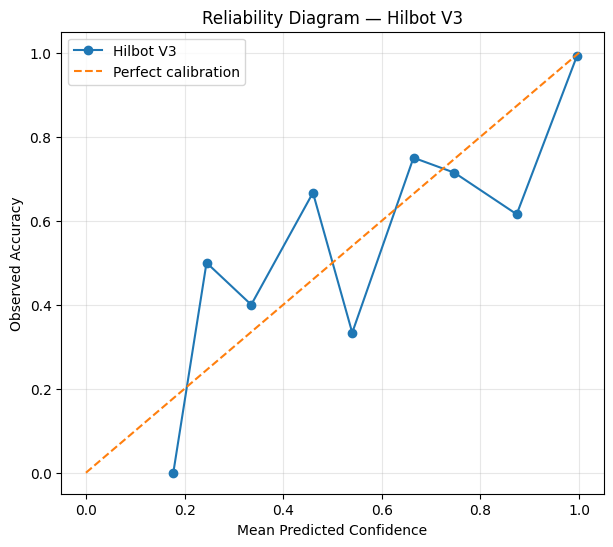

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    hilbot_calibration_table["mean_confidence"],
    hilbot_calibration_table["accuracy"],
    marker="o",
    label="Hilbot V3"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Observed Accuracy")
plt.title("Reliability Diagram — Hilbot V3")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [72]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Calibrated Linear SVM",
        "Hilbot V3"
    ],

    "Accuracy": [
        accuracy_score(y_test_clean, pred),
        accuracy_score(y_test_clean, svm_pred),
        hilbot_accuracy
    ],

    "Macro F1": [
        f1_score(
            y_test_clean,
            pred,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test_clean,
            svm_pred,
            average="macro",
            zero_division=0
        ),
        hilbot_macro_f1
    ],

    "Weighted F1": [
        f1_score(
            y_test_clean,
            pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test_clean,
            svm_pred,
            average="weighted",
            zero_division=0
        ),
        hilbot_weighted_f1
    ],

    "ECE": [
        ece_lr,
        svm_ece,
        hilbot_ece
    ],

    "Brier": [
        brier_lr,
        svm_brier,
        hilbot_brier
    ],

    "NLL": [
        nll_lr,
        svm_nll,
        hilbot_nll
    ],

    "Margin AUROC": [
        auc_margin,
        svm_auc_margin,
        hilbot_auc_margin
    ],

    "Margin AURC": [
        aurc(rc_margin),
        aurc(svm_rc_margin),
        aurc(hilbot_rc_margin)
    ]
})

display(model_comparison.round(4))

,Model,Accuracy,Macro F1,Weighted F1,ECE,Brier,NLL,Margin AUROC,Margin AURC
0,Logistic Regression,0.7770,0.5390,0.7943,0.5547,0.6814,1.7771,0.7950,0.0935
1,Calibrated Linear SVM,0.8164,0.5651,0.8166,0.1263,0.2552,0.6750,0.9243,0.0319
2,Hilbot V3,0.9148,0.8358,0.9173,0.0330,0.1296,0.3272,0.9487,0.0082


In [73]:
def evaluate_hilbot_condition(
    name,
    eval_df,
    model,
    tokenizer,
    vectorizer,
    label_encoder,
    max_len=30
):

    texts = eval_df["text"].astype(str)
    true_labels = eval_df["label"].astype(str).values

    # Sequence input
    sequences = tokenizer.texts_to_sequences(texts)

    seq_input = pad_sequences(
        sequences,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    # TF-IDF input — transform ONLY
    tfidf_input = vectorizer.transform(
        texts
    ).toarray().astype("float32")

    probs = model.predict(
        [seq_input, tfidf_input],
        verbose=0
    )

    pred_idx = np.argmax(
        probs,
        axis=1
    )

    predicted_labels = label_encoder.inverse_transform(
        pred_idx
    )

    sorted_probs = np.sort(
        probs,
        axis=1
    )

    confidence = sorted_probs[:, -1]

    margin = (
        sorted_probs[:, -1]
        - sorted_probs[:, -2]
    )

    entropy = -np.sum(
        probs * np.log(probs + 1e-12),
        axis=1
    )

    correct = (
        predicted_labels == true_labels
    )

    results = pd.DataFrame({
        "condition": name,
        "text": texts.values,
        "true_label": true_labels,
        "predicted_label": predicted_labels,
        "correct": correct,
        "confidence": confidence,
        "margin": margin,
        "entropy": entropy
    })

    metrics = {
        "condition": name,
        "n": len(true_labels),

        "accuracy":
            accuracy_score(
                true_labels,
                predicted_labels
            ),

        "macro_f1":
            f1_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                true_labels,
                predicted_labels,
                average="weighted",
                zero_division=0
            ),

        "mean_confidence":
            confidence.mean(),

        "mean_margin":
            margin.mean(),

        "mean_entropy":
            entropy.mean()
    }

    if len(np.unique(correct)) == 2:

        metrics["auroc_confidence"] = roc_auc_score(
            correct.astype(int),
            confidence
        )

        metrics["auroc_margin"] = roc_auc_score(
            correct.astype(int),
            margin
        )

        metrics["auroc_entropy"] = roc_auc_score(
            correct.astype(int),
            -entropy
        )

    else:

        metrics["auroc_confidence"] = np.nan
        metrics["auroc_margin"] = np.nan
        metrics["auroc_entropy"] = np.nan

    return results, metrics

In [74]:
hilbot_clean_typo_results, hilbot_clean_typo_metrics = evaluate_hilbot_condition(
    "Clean matched — Typo",
    clean_typo,
    hilbot_v3,
    tokenizer,
    tfidf,
    label_encoder
)

hilbot_typo_results, hilbot_typo_metrics = evaluate_hilbot_condition(
    "Typo",
    typo_eval,
    hilbot_v3,
    tokenizer,
    tfidf,
    label_encoder
)


hilbot_clean_abbrev_results, hilbot_clean_abbrev_metrics = evaluate_hilbot_condition(
    "Clean matched — Abbreviation",
    clean_abbrev,
    hilbot_v3,
    tokenizer,
    tfidf,
    label_encoder
)

hilbot_abbrev_results, hilbot_abbrev_metrics = evaluate_hilbot_condition(
    "Abbreviation",
    abbrev_eval,
    hilbot_v3,
    tokenizer,
    tfidf,
    label_encoder
)


hilbot_clean_short_results, hilbot_clean_short_metrics = evaluate_hilbot_condition(
    "Clean matched — Shortened",
    clean_short,
    hilbot_v3,
    tokenizer,
    tfidf,
    label_encoder
)

hilbot_short_results, hilbot_short_metrics = evaluate_hilbot_condition(
    "Shortened",
    short_eval,
    hilbot_v3,
    tokenizer,
    tfidf,
    label_encoder
)

In [75]:
hilbot_matched_summary = pd.DataFrame([
    hilbot_clean_typo_metrics,
    hilbot_typo_metrics,

    hilbot_clean_abbrev_metrics,
    hilbot_abbrev_metrics,

    hilbot_clean_short_metrics,
    hilbot_short_metrics
])

display(
    hilbot_matched_summary.round(4)
)

,condition,n,accuracy,macro_f1,weighted_f1,mean_confidence,mean_margin,mean_entropy,auroc_confidence,auroc_margin,auroc_entropy
0,Clean matched — Typo,303,0.9142,0.8340,0.9167,0.9258,0.8890,0.2385,0.9474,0.9495,0.9446
1,Typo,303,0.7855,0.5394,0.7860,0.8634,0.7938,0.4297,0.9134,0.9051,0.9211
2,Clean matched — Abbreviation,106,0.7925,0.8152,0.7840,0.8392,0.7549,0.5113,0.8523,0.8593,0.8447
3,Abbreviation,106,0.6038,0.5686,0.5833,0.7520,0.6360,0.7830,0.8437,0.8285,0.8482
4,Clean matched — Shortened,116,0.7931,0.7922,0.7907,0.8305,0.7450,0.5449,0.8528,0.8569,0.8478
5,Shortened,116,0.7155,0.7248,0.7038,0.7922,0.6889,0.6673,0.8441,0.8310,0.8478


In [77]:
hilbot_paired_summary = pd.DataFrame([
    paired_condition_analysis(
        "Typo",
        hilbot_clean_typo_results,
        hilbot_typo_results
    ),

    paired_condition_analysis(
        "Abbreviation",
        hilbot_clean_abbrev_results,
        hilbot_abbrev_results
    ),

    paired_condition_analysis(
        "Shortened",
        hilbot_clean_short_results,
        hilbot_short_results
    )
])

display(
    hilbot_paired_summary.round(4)
)

,condition,n,both_correct,harmed_correct_to_wrong,helped_wrong_to_correct,both_wrong,accuracy_change,mcnemar_p,mean_confidence_change,confidence_p,mean_margin_change,margin_p,mean_entropy_change,entropy_p
0,Typo,303,236,41,2,24,-0.1287,0.0000,-0.0624,0.0000,-0.0952,0.0000,0.1911,0.0000
1,Abbreviation,106,64,20,0,22,-0.1887,0.0000,-0.0873,0.0001,-0.1189,0.0001,0.2718,0.0000
2,Shortened,116,81,11,2,22,-0.0776,0.0225,-0.0383,0.0055,-0.0561,0.0195,0.1224,0.0014


In [79]:
# ============================================================
# EXPERIMENT 5 — DISTILBERT
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import TensorDataset, DataLoader
from torch.nn import CrossEntropyLoss

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

import transformers
print("Transformers:", transformers.__version__)

Device: cpu
PyTorch: 2.11.0+cpu
Transformers: 5.13.1


In [80]:
# Same indices previously used by Hilbot V3

distil_train_df = train_df.iloc[
    train_idx
].reset_index(drop=True)

distil_val_df = train_df.iloc[
    val_idx
].reset_index(drop=True)

distil_test_df = test_df.reset_index(
    drop=True
)

y_distil_train = label_encoder.transform(
    distil_train_df["label"].astype(str)
)

y_distil_val = label_encoder.transform(
    distil_val_df["label"].astype(str)
)

y_distil_test = label_encoder.transform(
    distil_test_df["label"].astype(str)
)

print("Training  :", len(distil_train_df))
print("Validation:", len(distil_val_df))
print("Test      :", len(distil_test_df))
print("Classes   :", NUM_CLASSES)

Training  : 1037
Validation: 183
Test      : 305
Classes   : 33


In [81]:
MODEL_NAME = "distilbert/distilbert-base-uncased"
MAX_BERT_LEN = 64

distil_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

def tokenize_texts(texts):

    return distil_tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_BERT_LEN,
        return_tensors="pt"
    )


train_enc = tokenize_texts(
    distil_train_df["text"].astype(str)
)

val_enc = tokenize_texts(
    distil_val_df["text"].astype(str)
)

test_enc = tokenize_texts(
    distil_test_df["text"].astype(str)
)

print(
    "Train input shape:",
    train_enc["input_ids"].shape
)

print(
    "Validation shape:",
    val_enc["input_ids"].shape
)

print(
    "Test shape:",
    test_enc["input_ids"].shape
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train input shape: torch.Size([1037, 64])
Validation shape: torch.Size([183, 64])
Test shape: torch.Size([305, 64])


In [82]:
BATCH_SIZE = 16

train_dataset_bert = TensorDataset(
    train_enc["input_ids"],
    train_enc["attention_mask"],
    torch.tensor(
        y_distil_train,
        dtype=torch.long
    )
)

val_dataset_bert = TensorDataset(
    val_enc["input_ids"],
    val_enc["attention_mask"],
    torch.tensor(
        y_distil_val,
        dtype=torch.long
    )
)

test_dataset_bert = TensorDataset(
    test_enc["input_ids"],
    test_enc["attention_mask"],
    torch.tensor(
        y_distil_test,
        dtype=torch.long
    )
)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader_bert = DataLoader(
    train_dataset_bert,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

val_loader_bert = DataLoader(
    val_dataset_bert,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_bert = DataLoader(
    test_dataset_bert,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches  :", len(train_loader_bert))
print("Validation batches:", len(val_loader_bert))
print("Test batches      :", len(test_loader_bert))

Training batches  : 65
Validation batches: 12
Test batches      : 20


In [83]:
id2label = {
    i: label
    for i, label in enumerate(
        label_encoder.classes_
    )
}

label2id = {
    label: i
    for i, label in id2label.items()
}

distilbert_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        id2label=id2label,
        label2id=label2id
    )
)

distilbert_model.to(DEVICE)

# Same class-weighting principle used earlier
bert_class_weights = np.array(
    [
        hilbot_class_weights[i]
        for i in range(NUM_CLASSES)
    ],
    dtype=np.float32
)

bert_class_weights = torch.tensor(
    bert_class_weights,
    dtype=torch.float32,
    device=DEVICE
)

bert_loss_fn = CrossEntropyLoss(
    weight=bert_class_weights
)

optimizer = torch.optim.AdamW(
    distilbert_model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

print("DistilBERT loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded.


In [84]:
def evaluate_bert_loader(
    model,
    loader
):

    model.eval()

    all_true = []
    all_pred = []

    total_loss = 0.0

    with torch.no_grad():

        for batch in loader:

            input_ids = batch[0].to(DEVICE)
            attention_mask = batch[1].to(DEVICE)
            labels = batch[2].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = bert_loss_fn(
                logits,
                labels
            )

            total_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_true.extend(
                labels.cpu().numpy()
            )

            all_pred.extend(
                predictions.cpu().numpy()
            )

    macro_f1 = f1_score(
        all_true,
        all_pred,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(
        all_true,
        all_pred
    )

    return {
        "loss":
            total_loss / len(loader),

        "accuracy":
            accuracy,

        "macro_f1":
            macro_f1
    }

In [85]:
MAX_EPOCHS = 5
PATIENCE = 3

best_val_macro_f1 = -np.inf
best_epoch_bert = None
best_state_bert = None

patience_counter = 0

bert_history = []

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    distilbert_model.train()

    train_loss = 0.0

    for batch in train_loader_bert:

        input_ids = batch[0].to(DEVICE)
        attention_mask = batch[1].to(DEVICE)
        labels = batch[2].to(DEVICE)

        optimizer.zero_grad()

        outputs = distilbert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        loss = bert_loss_fn(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            distilbert_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(
        train_loader_bert
    )

    val_metrics = evaluate_bert_loader(
        distilbert_model,
        val_loader_bert
    )

    bert_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss":
            val_metrics["loss"],
        "val_accuracy":
            val_metrics["accuracy"],
        "val_macro_f1":
            val_metrics["macro_f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train loss={train_loss:.4f} | "
        f"val loss={val_metrics['loss']:.4f} | "
        f"val acc={val_metrics['accuracy']:.4f} | "
        f"val macro F1={val_metrics['macro_f1']:.4f}"
    )

    if (
        val_metrics["macro_f1"]
        > best_val_macro_f1
    ):

        best_val_macro_f1 = (
            val_metrics["macro_f1"]
        )

        best_epoch_bert = epoch

        best_state_bert = copy.deepcopy(
            distilbert_model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print(
                "Early stopping."
            )
            break

Epoch 1 | train loss=3.4144 | val loss=3.2232 | val acc=0.4372 | val macro F1=0.1826
Epoch 2 | train loss=3.0004 | val loss=2.7117 | val acc=0.7541 | val macro F1=0.4343
Epoch 3 | train loss=2.4402 | val loss=2.1781 | val acc=0.8525 | val macro F1=0.6932
Epoch 4 | train loss=1.9065 | val loss=1.6741 | val acc=0.8907 | val macro F1=0.7919
Epoch 5 | train loss=1.4493 | val loss=1.2519 | val acc=0.8907 | val macro F1=0.7841


In [ ]:
distilbert_model.load_state_dict(
    best_state_bert
)

distilbert_model.to(DEVICE)
distilbert_model.eval()

all_logits = []
all_true = []

with torch.no_grad():

    for batch in test_loader_bert:

        input_ids = batch[0].to(DEVICE)
        attention_mask = batch[1].to(DEVICE)
        labels = batch[2].to(DEVICE)

        outputs = distilbert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        all_logits.append(
            outputs.logits.cpu()
        )

        all_true.extend(
            labels.cpu().numpy()
        )

bert_test_logits = torch.cat(
    all_logits,
    dim=0
)

bert_probs = torch.softmax(
    bert_test_logits,
    dim=1
).numpy()

bert_pred_encoded = np.argmax(
    bert_probs,
    axis=1
)

bert_pred = label_encoder.inverse_transform(
    bert_pred_encoded
)

bert_true = label_encoder.inverse_transform(
    np.asarray(all_true)
)

bert_accuracy = accuracy_score(
    bert_true,
    bert_pred
)

bert_macro_f1 = f1_score(
    bert_true,
    bert_pred,
    average="macro",
    zero_division=0
)

bert_weighted_f1 = f1_score(
    bert_true,
    bert_pred,
    average="weighted",
    zero_division=0
)

print("Best epoch:", best_epoch_bert)

print(
    f"DistilBERT Accuracy    : "
    f"{bert_accuracy:.4f}"
)

print(
    f"DistilBERT Macro F1    : "
    f"{bert_macro_f1:.4f}"
)

print(
    f"DistilBERT Weighted F1 : "
    f"{bert_weighted_f1:.4f}"
)

In [ ]:
BERT_SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Hilbot chatbot (1)/Hilbot-FI/"
    "distilbert_selective"
)

distilbert_model.save_pretrained(
    BERT_SAVE_DIR
)

distil_tokenizer.save_pretrained(
    BERT_SAVE_DIR
)

print(
    "DistilBERT saved to:",
    BERT_SAVE_DIR
)